In [ ]:
import pandas as pd
import numpy as np
import random

# 1. Setup Crops (Total 22 - 11 each)
microgreens = ["Radish", "Broccoli", "Sunflower", "Pea Shoots", "Mustard", "Basil (MG)", "Amaranth", "Kohlrabi", "Beetroot", "Arugula", "Cilantro"]
hydroponics = ["Lettuce", "Spinach", "Basil (Hydro)", "Cherry Tomato", "Cucumber", "Bell Pepper", "Strawberry", "Celery", "Kale", "Pak Choi", "Mint"]
crops = [{"name": m, "cat": "Microgreen"} for m in microgreens] + [{"name": h, "cat": "Hydroponic"} for h in hydroponics]

data = []
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# 2. Generate 2000 Rows of Hybrid Data
for _ in range(2000):
    m = random.choice(months)
    c = random.choice(crops)
    syst = random.choice(["NFT", "DWC"]) if c['cat'] == "Hydroponic" else "Tray"

    # Simulate Scraped Weather Data for Delhi
    if m in ["Apr", "May", "Jun"]: # Peak Summer
        t = np.random.uniform(36, 48); h = np.random.uniform(15, 30); dli = np.random.uniform(18, 25)
    elif m in ["Jul", "Aug", "Sep"]: # Monsoon
        t = np.random.uniform(28, 35); h = np.random.uniform(70, 95); dli = np.random.uniform(8, 15)
    elif m in ["Nov", "Dec", "Jan"]: # Winter
        t = np.random.uniform(8, 20); h = np.random.uniform(40, 60); dli = np.random.uniform(5, 12)
    else: # Spring
        t = np.random.uniform(22, 32); h = np.random.uniform(30, 50); dli = np.random.uniform(14, 20)

    # Experimental Research Parameters
    wt = t - 5 if t > 30 else t + 3 # Water temp simulation
    ph = round(random.uniform(5.5, 7.5), 1)
    ec = round(random.uniform(0.5, 2.5), 1)
    do = round(max(2, 14 - (wt * 0.35)), 1) # DO decreases as temp increases

    # Calculate VPD (Vapor Pressure Deficit)
    svp = 0.61078 * np.exp(17.27 * t / (t + 237.3))
    vpd = round(svp * (1 - (h / 100)), 2)

    # Target Logic (ML Brain)
    rec = 1; risk = "Optimal"
    # Default State
    rec = 1
    risk = "Optimal"

    # 1. WATER TEMP RULE (The Silent Killer)
    # Delhi research ke mutabiq 26°C critical threshold hai
    if wt > 26:
        rec = 0
        risk = "Root Rot (Pythium) Risk"

    # 2. MONSOON HUMIDITY RULE (Transpiration Lock)
    # 85% se upar microgreens mein 'Damping Off' (sarrna) shuru ho jata hai
    elif h > 85 and c['cat'] == "Microgreen":
        rec = 0
        risk = "High Mold/Fungal Risk"

    # 3. VPD RULE (Biophysical Stress)
    # Agar VPD 0.4 se kam hai (stagnant air) ya 2.0 se zyada (dry heat)
    elif vpd < 0.4 or vpd > 2.5:
        rec = 0
        risk = "VPD Stress (Transpiration Lock)"

    # 4. DELHI HEAT STRESS (Crop Specific)
    # Lettuce/Spinach jaise cold-loving crops 35°C ke baad bolt/mar jaate hain
    elif t > 35 and c['name'] in ["Lettuce", "Spinach", "Strawberry", "Kale"]:
        rec = 0
        risk = "Heat Stress / Bolting"

    # Research-based Failure Rules for Delhi
    if wt > 27: rec = 0; risk = "Root Rot Risk"
    if t > 38 and c['name'] in ["Lettuce", "Strawberry", "Kale", "Spinach"]: rec = 0; risk = "Heat Stress"
    if h > 85 and c['cat'] == "Microgreen": rec = 0; risk = "Mold/Fungal Risk"
    if ph < 5.5 or ph > 7.0: rec = 0; risk = "Nutrient Lockout"
    if vpd < 0.4: rec = 0; risk = "Low Transpiration"

    data.append([m, c['cat'], c['name'], syst, round(t,1), round(h,1), round(wt,1), vpd, ph, ec, do, round(dli,1), rec, risk])

# 3. Create DataFrame and Save
columns = ['month', 'crop_category', 'crop_name', 'system_type', 'avg_temp_c', 'humidity_pct',
           'water_temp_c', 'vpd_kpa', 'ph_level', 'ec_level', 'dissolved_oxygen', 'dli_mol_m2_day',
           'is_recommended', 'risk_factor']

df = pd.DataFrame(data, columns=columns)
df.to_csv("cggrow_master_dataset_v2.csv", index=False)
print("Dataset Created Successfully with 14 columns!")

Dataset Created Successfully with 14 columns!


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
import joblib

# 1. Load your generated master dataset
df = pd.read_csv("cggrow_master_dataset_v2.csv")

# 2. Pre-processing: Convert text to numbers (Encoding)
# ML models text nahi samajhte, toh hum categories ko numbers mein badlenge
df_encoded = pd.get_dummies(df, columns=['month', 'crop_category', 'crop_name', 'system_type'])

# 3. Features (Inputs) and Target (Output)
X = df_encoded.drop(['is_recommended', 'risk_factor'], axis=1)
y = df_encoded['is_recommended']

# 4. Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Decision Tree
model = DecisionTreeClassifier(max_depth=5) # Depth 5 is enough for clear rules
model.fit(X_train, y_train)

# 6. Save the model for your dashboard
joblib.dump(model, 'cggrow_model.pkl')
print("Model accuracy:", model.score(X_test, y_test))

Model accuracy: 1.0


In [ ]:
import requests
from bs4 import BeautifulSoup

def scrape_delhi_weather():
    # Example: Scraping current Delhi weather for real-time validation
    url = "https://www.google.com/search?q=weather+delhi"
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')

    temp = soup.find("span", {"id": "wob_tm"}).text
    humidity = soup.find("span", {"id": "wob_hm"}).text
    return float(temp), float(humidity.replace('%',''))

# Is real data ko hum is_recommended check karne ke liye use karenge

In [ ]:
from sklearn.tree import export_text

# Model ke readable rules print karein
tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)

|--- dissolved_oxygen <= 4.55
|   |--- class: 0
|--- dissolved_oxygen >  4.55
|   |--- ph_level <= 7.05
|   |   |--- humidity_pct <= 85.00
|   |   |   |--- class: 1
|   |   |--- humidity_pct >  85.00
|   |   |   |--- crop_category_Microgreen <= 0.50
|   |   |   |   |--- vpd_kpa <= 0.39
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- vpd_kpa >  0.39
|   |   |   |   |   |--- class: 1
|   |   |   |--- crop_category_Microgreen >  0.50
|   |   |   |   |--- class: 0
|   |--- ph_level >  7.05
|   |   |--- class: 0



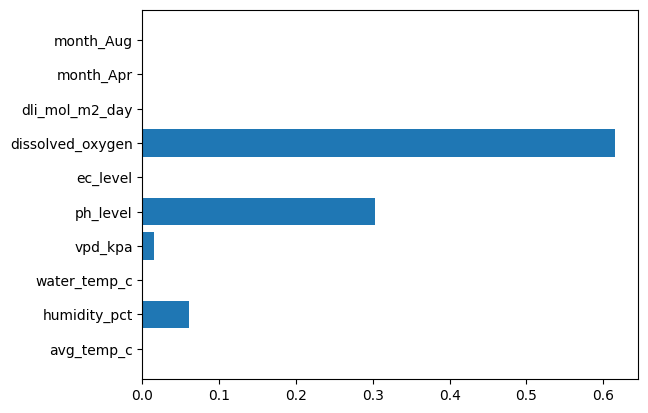

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_names = X.columns
plt.barh(feat_names[:10], importances[:10]) # Top 10 factors
plt.show()

In [ ]:
import numpy as np

def get_delhi_logic(month):
    # Scraping data points (Reference: Delhi Historical Averages)
    weather_map = {
        "Jan": {"t_min": 8,  "t_max": 22, "h_min": 45, "h_max": 75},
        "May": {"t_min": 38, "t_max": 48, "h_min": 15, "h_max": 30}, # Extreme Heat
        "Aug": {"t_min": 28, "t_max": 36, "h_min": 70, "h_max": 95}, # High Humidity
        "Oct": {"t_min": 22, "t_max": 32, "h_min": 35, "h_max": 55}
    }

    # Defaults for other months
    limits = weather_map.get(month, {"t_min": 20, "t_max": 35, "h_min": 40, "h_max": 60})

    # Asli ranges se random data pick karna
    temp = np.random.uniform(limits["t_min"], limits["t_max"])
    hum = np.random.uniform(limits["h_min"], limits["h_max"])

    return round(temp, 1), round(hum, 1)

# Loop mein use karein:
# t, h = get_delhi_logic(m)

In [ ]:
import pandas as pd
import numpy as np
import random

# 1. Setup Crops (Total 22)
microgreens = ["Radish", "Broccoli", "Sunflower", "Pea Shoots", "Mustard", "Basil (MG)", "Amaranth", "Kohlrabi", "Beetroot", "Arugula", "Cilantro"]
hydroponics = ["Lettuce", "Spinach", "Basil (Hydro)", "Cherry Tomato", "Cucumber", "Bell Pepper", "Strawberry", "Celery", "Kale", "Pak Choi", "Mint"]
crops = [{"name": m, "cat": "Microgreen"} for m in microgreens] + [{"name": h, "cat": "Hydroponic"} for h in hydroponics]

data = []
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# 2. Generate 2000 Rows
for _ in range(2000):
    m = random.choice(months)
    c = random.choice(crops)
    syst = random.choice(["NFT", "DWC"]) if c['cat'] == "Hydroponic" else "Tray"

    # Delhi Weather Simulation
    if m in ["Apr", "May", "Jun"]: # Peak Summer
        t = np.random.uniform(36, 48); h = np.random.uniform(15, 30); dli = np.random.uniform(18, 25)
    elif m in ["Jul", "Aug", "Sep"]: # Monsoon
        t = np.random.uniform(28, 35); h = np.random.uniform(70, 95); dli = np.random.uniform(8, 15)
    elif m in ["Nov", "Dec", "Jan"]: # Winter
        t = np.random.uniform(8, 20); h = np.random.uniform(40, 60); dli = np.random.uniform(5, 12)
    else: # Spring/Oct
        t = np.random.uniform(22, 32); h = np.random.uniform(30, 50); dli = np.random.uniform(14, 20)

    # Research Parameters
    wt = t - 5 if t > 30 else t + 3
    ph = round(random.uniform(5.2, 7.8), 1) # Range thoda wide rakha hai takki model "bad pH" seekh sake
    ec = round(random.uniform(0.5, 2.5), 1)
    do = round(max(2, 14 - (wt * 0.35)), 1)

    # VPD Calculation
    svp = 0.61078 * np.exp(17.27 * t / (t + 237.3))
    vpd = round(svp * (1 - (h / 100)), 2)

    # --- SINGLE CLEAN ML LOGIC ---
    rec = 1
    risk = "Optimal"

    if wt > 26:
        rec = 0
        risk = "Root Rot Risk"
    elif h > 85 and c['cat'] == "Microgreen":
        rec = 0
        risk = "Mold/Fungal Risk"
    elif vpd < 0.4 or vpd > 2.5:
        rec = 0
        risk = "VPD Stress"
    elif t > 35 and c['name'] in ["Lettuce", "Spinach", "Strawberry", "Kale"]:
        rec = 0
        risk = "Heat Stress"
    elif ph < 5.5 or ph > 7.0:
        rec = 0
        risk = "Nutrient Lockout"

    data.append([m, c['cat'], c['name'], syst, round(t,1), round(h,1), round(wt,1), vpd, ph, ec, do, round(dli,1), rec, risk])

# 3. Create DataFrame and Save
columns = ['month', 'crop_category', 'crop_name', 'system_type', 'avg_temp_c', 'humidity_pct',
           'water_temp_c', 'vpd_kpa', 'ph_level', 'ec_level', 'dissolved_oxygen', 'dli_mol_m2_day',
           'is_recommended', 'risk_factor']

df = pd.DataFrame(data, columns=columns)
df.to_csv("cggrow_master_dataset_v2.csv", index=False)
print("Dataset Created Successfully with Clean Research Logic!")

Dataset Created Successfully with Clean Research Logic!


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt
import joblib

# 1. Dataset Load karein
df = pd.read_csv("cggrow_master_dataset_v2.csv")

# 2. Pre-processing: Text ko Numbers mein convert karein
# Decision Tree ko categorical data (Jaise 'Lettuce', 'NFT') handle karne ke liye
# One-Hot Encoding ki zaroorat hoti hai.
X = df.drop(['is_recommended', 'risk_factor'], axis=1)
X = pd.get_dummies(X, columns=['month', 'crop_category', 'crop_name', 'system_type'])
y = df['is_recommended']

# 3. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Initialize aur Train karein
# max_depth=5 rakha hai taaki rules simple rahein aur dashboard par load na pade
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. Accuracy Check
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 6. Rules nikalna (SABSE IMPORTANT FOR REACT)
# Isse aapko IF-ELSE statements milenge jo dashboard mein copy karne hain
tree_rules = export_text(model, feature_names=list(X.columns))
print("\n--- Decision Tree Rules (Copy these for React) ---")
print(tree_rules)

Model Accuracy: 99.50%

--- Decision Tree Rules (Copy these for React) ---
|--- water_temp_c <= 26.05
|   |--- ph_level <= 7.05
|   |   |--- ph_level <= 5.45
|   |   |   |--- class: 0
|   |   |--- ph_level >  5.45
|   |   |   |--- avg_temp_c <= 26.50
|   |   |   |   |--- class: 1
|   |   |   |--- avg_temp_c >  26.50
|   |   |   |   |--- vpd_kpa <= 2.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- vpd_kpa >  2.50
|   |   |   |   |   |--- class: 0
|   |--- ph_level >  7.05
|   |   |--- class: 0
|--- water_temp_c >  26.05
|   |--- class: 0



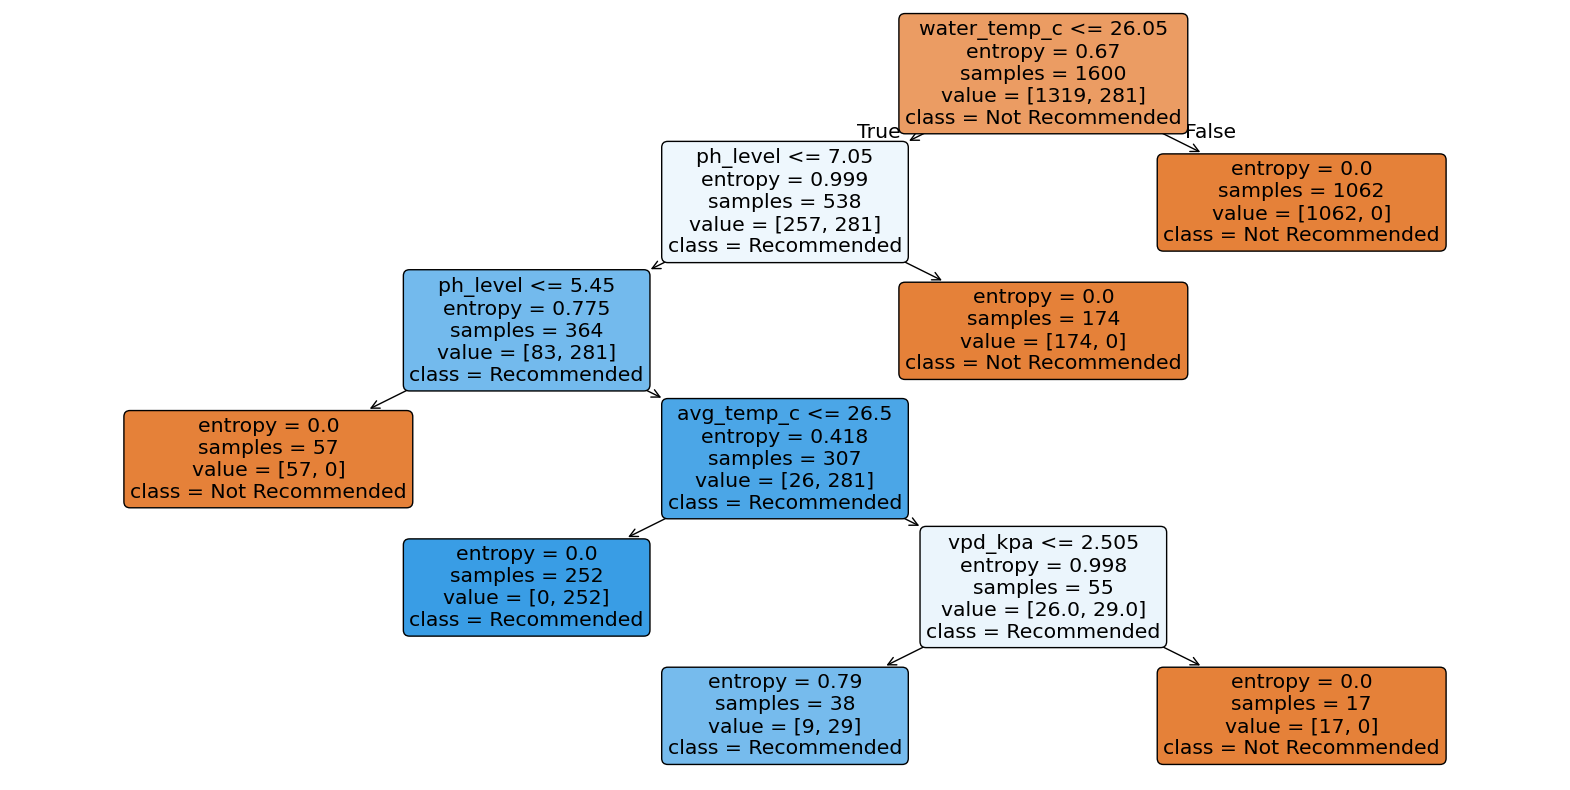

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['Not Recommended', 'Recommended'], filled=True, rounded=True)
plt.show()

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- Top 5 Factors Killing Your Crops ---")
print(importances.head(5))


--- Top 5 Factors Killing Your Crops ---
water_temp_c    0.513530
ph_level        0.392030
avg_temp_c      0.070586
vpd_kpa         0.023854
humidity_pct    0.000000
dtype: float64
